# `jitr` Quickstart: $\alpha$ elastic scattering on $^{48}$Ca at 29 MeV

We will 
- compile a solver for a particular reaction and kinematics
-  define a parametric potential and generate samples of the interaction parameters
-  perform a Bayesian calibration of the parameters to experimental data from [EXFOR](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=14669&subID=150567004&plus=1)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

### Read in data

In [2]:
import pandas as pd

df = pd.read_csv(
    "./alpha_ca48_ratio_ruth.txt", names=["angle", "xs", "xs_err"], skiprows=1
)

In [3]:
df.head()

,angle,xs,xs_err
0,14.718,0.57851,0.030926
1,15.562,0.50721,0.027360
2,15.985,0.46463,0.025232
3,16.408,0.41639,0.022819
4,18.088,0.46469,0.025234


In [4]:
x = df["angle"].to_numpy()
y = df["xs"].to_numpy()
y_err = df["xs_err"].to_numpy()

## Set up reaction and compile solver

In [5]:
from jitr.reactions.reaction import Reaction
from jitr.rmatrix import Solver as SolverKernel
from jitr.utils import utils
from jitr.xs import elastic

# define reaction system
alpha = (4, 2)
Ca48 = (48, 20)
reaction = Reaction(target=Ca48, projectile=alpha, process="El")

# calculate kinematics for a given lab energy
energy_lab = 28.2
kinematics = reaction.kinematics(energy_lab)

# set the channel radius, number of nodes, and number of partial waves
interaction_range_fm = 1.2 * (48 ** (1 / 3) + 4 ** (1 / 3)) + 2
channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
    interaction_range_fm, kinematics.k
)
channel_radius = channel_radius_dimensionless / kinematics.k
N = utils.suggested_basis_size(channel_radius_dimensionless)
lmax = 180

# build a solver for the system and reaction of interest
print(f"Compiling solver for {reaction} at {energy_lab} MeV")
print(f" - channel radius {channel_radius:1.2f} fm")
print(f" - {N} nodes")
print(f" - {lmax} partial waves")

solver = elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius,
    solver=SolverKernel(N),
    lmax=lmax,
    angles=np.deg2rad(x),
)
rgrid = solver.radial_grid()
# jit warmup
_ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))
print("Done!")

Compiling solver for 48-Ca(alpha,el) at 28.2 MeV
 - channel radius 11.19 fm
 - 40 nodes
 - 180 partial waves
Done!


## Define the interaction model and parameters

In [6]:
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere as coulomb,
)
from jitr.optical_potentials.potential_forms import (
    woods_saxon_safe as ws,
)

In [7]:
def U_central(r, Vv, Wv, Rv, av, Rw, aw):
    return -Vv * ws(r, Rv, av) - 1j * Wv * ws(r, Rw, aw)


def V_Coulomb(r, Zz, RC):
    return coulomb(r, Zz, RC)

In [8]:
def calculate_xs_ratio(theta):
    Vv, Wv, rv, av, rw, aw = theta
    A_factor = reaction.target.A ** (1 / 3)
    Zz = reaction.target.Z * reaction.projectile.Z
    xs = solver.xs(
        central_potential=U_central(
            rgrid,
            Vv,
            Wv,
            rv * A_factor,
            av,
            rw * A_factor,
            aw,
        ),
        coulomb_potential=V_Coulomb(rgrid, Zz, 1.3 * A_factor),
    )
    return xs.dsdo / solver.rutherford

## Comparison to data

In [9]:
log_err_term = np.sum(np.log(2 * np.pi * y_err))


def log_likelihood(theta):
    y_pred = calculate_xs_ratio(theta)
    chi2 = np.sum((y_pred - y) ** 2 / y_err * 2)
    logl = -0.5 * (chi2 + log_err_term)
    return logl

In [10]:
theta_0 = np.array([185, 25, 1.4, 0.5, 1.4, 0.4])
log_likelihood(theta_0)

np.float64(312.92853381102304)

In [11]:
theta_bounds = np.array(
    [
        [120, 250],
        [5, 50],
        [1.15, 1.6],
        [0.4, 0.8],
        [1.1, 1.8],
        [0.4, 0.9],
    ]
)

## Maximum likelihood estimation (MLE)

Now that we have the solver compiled, fitting to data is easy. Notice that, since `y_err` is fixed and there is no correlation in the errors, the MLE in this case is in fact identical to the $\chi^2$-minimizing solution.

In [12]:
from scipy.optimize import minimize

In [13]:
%%time
optimum = minimize(
    lambda x: -log_likelihood(x),
    theta_0,
    method="Nelder-Mead",
    bounds=theta_bounds,
    options={
        "maxiter": 5000,
        "adaptive": True,
    },
)
optimum

CPU times: user 4.4 s, sys: 1.12 ms, total: 4.41 s
Wall time: 4.41 s


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -540.6501336201458
             x: [ 1.806e+02  2.610e+01  1.509e+00  5.208e-01  1.401e+00
                  4.000e-01]
           nit: 452
          nfev: 775
 final_simplex: (array([[ 1.806e+02,  2.610e+01, ...,  1.401e+00,
                         4.000e-01],
                       [ 1.806e+02,  2.610e+01, ...,  1.401e+00,
                         4.000e-01],
                       ...,
                       [ 1.806e+02,  2.610e+01, ...,  1.401e+00,
                         4.000e-01],
                       [ 1.806e+02,  2.610e+01, ...,  1.401e+00,
                         4.000e-01]], shape=(7, 6)), array([-5.407e+02, -5.407e+02, -5.407e+02, -5.407e+02,
                       -5.407e+02, -5.407e+02, -5.407e+02]))

In [14]:
y_mlem = calculate_xs_ratio(optimum.x)

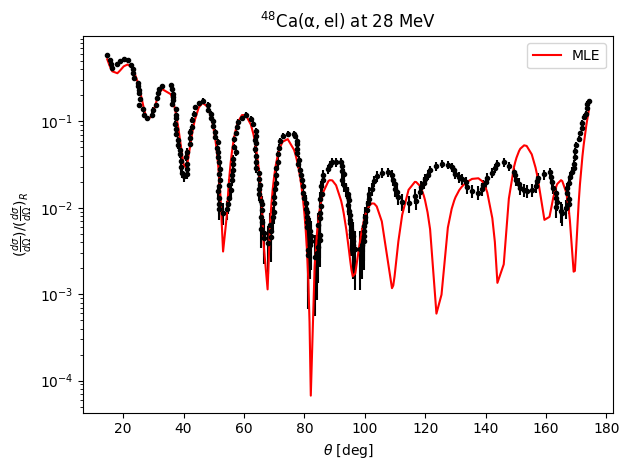

In [15]:
plt.figure()
plt.errorbar(df["angle"], df["xs"], y_err, color="k", marker=".", linestyle="none")
plt.plot(df["angle"], y_mlem, color="r", label="MLE")
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_{R}$")
plt.title(f"${reaction.reaction_latex}$ at {kinematics.Elab:1.0f} MeV")
plt.tight_layout()
plt.show()

Not a bad result! Notice, however, the degradation of the quality of the fit at backwards angles. This is due to model discrepancy - the simple 6 parameter model we're using is not flexible enough to resolve the full reaction dynamics.

## Bayesian calibration
To do Bayesian calibration, we must first define a prior. 

In [16]:
prior_means = theta_0
prior_std_devs = np.array([40, 10, 0.1, 0.1, 0.2, 0.2])
prior = stats.multivariate_normal(
    mean=prior_means,
    cov=np.diag(prior_std_devs) ** 2,
)

### Sampling from the posterior distribution
There are many open source sampler and calibration libraries out there in Python. In this example, we will use a neat one: [dynesty](https://dynesty.readthedocs.io/en/stable/quickstart.html). Rather than the usual Markov-Chain Monte Carlo, this does something called nested sampling.

Note that this should take 5-10 minutes to converge.

In [17]:
import dynesty

In [18]:
sampler_dyn = dynesty.NestedSampler(
    log_likelihood,
    lambda x: stats.norm.ppf(x, loc=prior_means, scale=prior_std_devs),
    prior_means.size,
    nlive=200,
    sample="rwalk",
)
sampler_dyn.run_nested(dlogz=1.0, print_progress=False)

In [19]:
results_dyn = sampler_dyn.results
flat_dynesty = results_dyn.samples_equal()

print(f"Posterior samples: {len(flat_dynesty)}")
print(f"log Z = {results_dyn.logz[-1]:.2f} ± {results_dyn.logzerr[-1]:.2f}")
print(f"Efficiency: {results_dyn.eff:.2f} %")

Posterior samples: 3201
log Z = 530.35 ± 0.55
Efficiency: 4.80 %


### Plot posterior distribution

In [20]:
import corner
from matplotlib.lines import Line2D

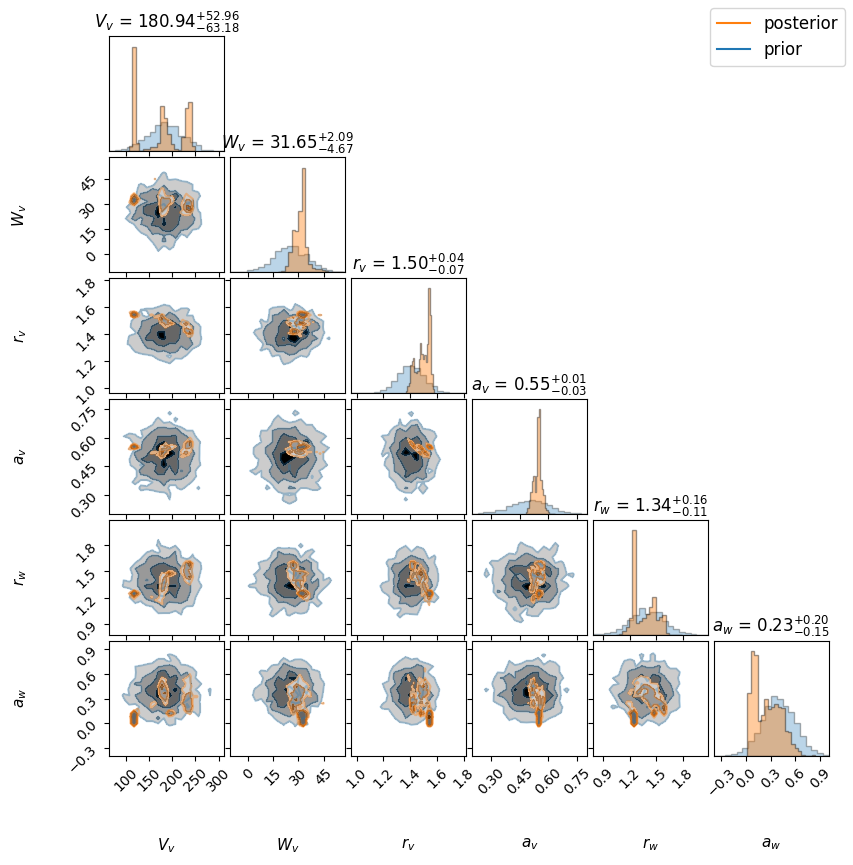

In [21]:
n_corner = 2000
prior_samples = prior.rvs(n_corner)
idx_d = np.random.default_rng(42).choice(
    len(flat_dynesty), min(n_corner, len(flat_dynesty)), replace=False
)

fig = plt.figure(figsize=(8, 8))


def corner_kwargs(color, alpha=0.4):
    return dict(
        labels=[
            r"$V_v$",
            r"$W_v$",
            r"$r_v$",
            r"$a_v$",
            r"$r_w$",
            r"$a_w$",
            "$r_C$",
        ],
        label_kwargs={"fontsize": 11},
        show_titles=True,
        plot_datapoints=False,
        plot_density=False,
        plot_contours=True,
        fill_contours=True,
        no_fill_contours=False,
        contour_kwargs={
            "colors": color,
            "linewidths": 1.5,
            "alpha": alpha,
        },
        hist_kwargs={
            "density": True,
            "histtype": "stepfilled",
            "alpha": alpha,
            "color": color,
            "edgecolor": "k",
        },
        labelpad=0.4,
    )


corner.corner(
    prior_samples,
    fig=fig,
    **corner_kwargs("tab:blue", alpha=0.3),
)
corner.corner(
    flat_dynesty[idx_d],
    fig=fig,
    **corner_kwargs("tab:orange"),
)

handles = [
    Line2D([0], [0], color="tab:orange", label="posterior"),
    Line2D([0], [0], color="tab:blue", label="prior"),
]
fig.legend(handles=handles, loc="upper right", fontsize=12)

Voila! Notice the famous *discrete ambiguity* in $V_v$. The real depth can take values of $\approx$100, 135, 165, 185, 220… MeV, each of which adds an interior node to the scattering wavefunction. Because this effect is roughly the same across all partial waves, ***the predicted cross sections are roughly the same for each value***. This is one of several well known "parameter ambiguities" observed when fitting optical potentials, and is discussed in (among other places) [this 1971 review paper by Hodgson](https://iopscience.iop.org/article/10.1088/0034-4885/34/2/306/meta).

In a Bayesian context, we recognize that these so-called ambiguities are really ***posterior multimodalities***. If one has a good reason to choose a particular mode (for example, microscopic esimtates of $V_v$ for $\alpha$ + $^{48}$Ca give $\sim 185$ MeV), then one can narrow their prior to focus on that mode. In this example, we intentionally kept the prior broad to exhibit this multimodality. We also intentionally chose to use nested sampling, as one of its advantages is graceful handling of multi-modal posteriors.

### Calculate predictive posterior

In [22]:
n_pred = 500
idx_d_pred = np.random.default_rng(43).choice(len(flat_dynesty), n_pred, replace=False)
y_pred_dynesty = np.array([calculate_xs_ratio(s) for s in flat_dynesty[idx_d_pred]])

### Plot predictive posterior distribution

We will plot the inner 90% credible interval (CI) of the posterior predictive distribution.

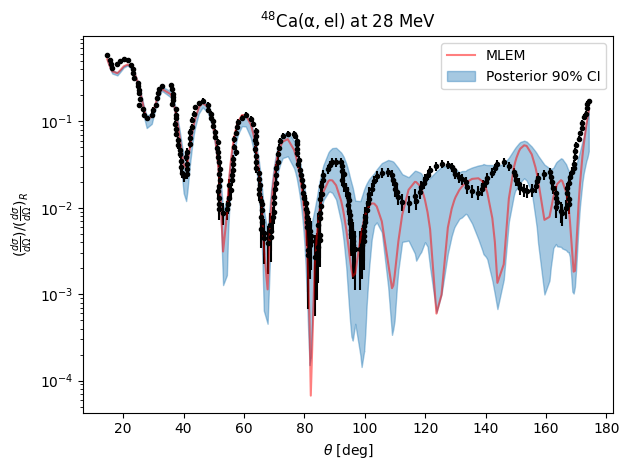

In [23]:
plt.figure()
plt.errorbar(df["angle"], df["xs"], y_err, color="k", marker=".", linestyle="none")
plt.plot(df["angle"], y_mlem, alpha=0.5, color="r", label="MLEM")
plt.fill_between(
    df["angle"],
    *np.percentile(y_pred_dynesty, [5, 95], axis=0),
    color="tab:blue",
    alpha=0.4,
    label="Posterior 90% CI",
)
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_{R}$")
plt.title(f"${reaction.reaction_latex}$ at {kinematics.Elab:1.0f} MeV")
plt.tight_layout()
plt.show()